In [9]:
"""

- Author: Tolib Abdurakhmonov
- Affiliation: Institute of Physics, University of Rostock
- Email: abdurakhmonov.t.z@gmail.com

========================================
This script can be used to calculate MSD and RMSD for MD simulaions. It will only accept xyz file 
and create datafiles and also plot them if you want to stay completely in python environment, but 
you free to use any other program/language to plot.
========================================
"""

#!/usr/bin/env python3
"""
xyz_msd_rmsd.py
===============

Compute mean-square displacement (MSD) and the simple root-mean-square
deviation (RMSD) of all atoms in an XYZ trajectory with respect to the
FIRST frame, then write a data table and (optionally) a plot.

* Works with plain XYZ or extended XYZ.
* Needs only NumPy + (optionally) Matplotlib.
* Handles arbitrarily large files by streaming - memory stays small.

Usage
-----
  python xyz_msd_rmsd.py input.xyz [--out MSD_RMSD.dat] [--dt 1]
                                   [--png rmsd.png] [--skip 10]

Options
-------
  --dt   timestep size in **fs** (floating-point). If omitted, the script
         tries to read a token like "Time=0.5" or "t=0.5" in every comment
         line and will fall back to the integer frame index if nothing
         looks like a time.
  --skip analyse every n-th frame (speeds up very long runs; default 1).
"""


'\nxyz_msd_rmsd.py\n===============\n\nCompute mean-square displacement (MSD) and the simple root-mean-square\ndeviation (RMSD) of all atoms in an XYZ trajectory with respect to the\nFIRST frame, then write a data table and (optionally) a plot.\n\n* Works with plain XYZ or extended XYZ.\n* Needs only NumPy + (optionally) Matplotlib.\n* Handles arbitrarily large files by streaming - memory stays small.\n\nUsage\n-----\n  python xyz_msd_rmsd.py input.xyz [--out MSD_RMSD.dat] [--dt 1]\n                                   [--png rmsd.png] [--skip 10]\n\nOptions\n-------\n  --dt   timestep size in **fs** (floating-point). If omitted, the script\n         tries to read a token like "Time=0.5" or "t=0.5" in every comment\n         line and will fall back to the integer frame index if nothing\n         looks like a time.\n  --skip analyse every n-th frame (speeds up very long runs; default 1).\n'

In [10]:
# Since the MD XYZ file contains frames after every 's'th interval (check simpleMD2() function in 5.ipynb)
# we state that the --dt in the MD XYZ needs to be (1*s) fs 
# here, s=10
# --skip : defines the resolution of the MD plot (does not effect interval)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def plot_and_fit_linear(file_path):
    df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)
    df.columns = ['time_ps', 'RMSD_Ang', 'MSD_Ang2']
    
    # Define fitting function
    def linear_func(t, D, c):
        return D * t + c
    
    # Define 10% and 90% time points
    time_min = df['time_ps'].min()
    time_max = df['time_ps'].max()
    time_10 = time_min + 0.10 * (time_max - time_min)
    time_90 = time_min + 0.90 * (time_max - time_min)
    
    # Extract data in the fitting window
    mask = (df['time_ps'] >= time_10) & (df['time_ps'] <= time_90)
    time_fit = df['time_ps'][mask].values
    msd_fit = df['MSD_Ang2'][mask].values
    
    # Fit linear function to MSD in the 10%-90% range
    popt, _ = curve_fit(linear_func, time_fit, msd_fit)
    slope, intercept = popt
    
    # Calculate diffusion coefficient (3D case: MSD = 6Dt)
    D_3D = slope / 6
    
    # Create the fit line for the full time range
    msd_linear_fit = linear_func(df['time_ps'], slope, intercept)
    fit_equation = f'MSD = {slope:.4f}·t + {intercept:.4f}'

    return df['time_ps'], msd_linear_fit, fit_equation
    
    # Plot and export
    plt.figure(figsize=(10, 6))
    plt.plot(df['time_ps'], df['MSD_Ang2'], label='MSD (Å²)', color='blue')
    plt.plot(df['time_ps'], msd_linear_fit, '--', color='black', label=fit_equation)
    plt.axvline(x=time_10, color='red', linestyle='--')
    plt.axvline(x=time_90, color='green', linestyle='--')
    plt.xlabel('Time (ps)')
    plt.ylabel('MSD (Å²)')
    plt.title(f'Linear Fit to MSD (10–90%) — Diffusion Coefficient D ≈ {D_3D:.4f} Å²/ps')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    # Save the figure
    plt.savefig("msd_linear_fit_100ps.png", dpi=300)
    plt.show()

# Load the data

In [13]:

!python3 MSD.py moldyn/mace_learned_N4000_md_1500K_100ps.xyz --dt 10 --out moldyn/output/gas_md1500K_100ps.dat --png moldyn/output/gas_md1500K_100ps.png --skip 1
plot_and_fit_linear(file_path = "moldyn/output/gas_md1500K_100ps.dat")

!python3 MSD.py moldyn/final_md_liquid_100ps.xyz --dt 10 --out moldyn/output/liquid_md1500K_100ps.dat --png moldyn/output/liquid_md1500K_100ps.png --skip 1
plot_and_fit_linear(file_path = "moldyn/output/liquid_md1500K_100ps.dat")

✔  wrote moldyn/output/gas_md1500K_100ps.dat  with 10001 lines
✔  wrote moldyn/output/gas_md1500K_100ps.png


/tmp/ipykernel_130463/1414552876.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


✔  wrote moldyn/output/liquid_md1500K_100ps.dat  with 10001 lines
✔  wrote moldyn/output/liquid_md1500K_100ps.png


/tmp/ipykernel_130463/1414552876.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


(0          0.00
 1          0.01
 2          0.02
 3          0.03
 4          0.04
           ...  
 9996      99.96
 9997      99.97
 9998      99.98
 9999      99.99
 10000    100.00
 Name: time_ps, Length: 10001, dtype: float64,
 0         21.241504
 1         21.253399
 2         21.265294
 3         21.277189
 4         21.289084
             ...    
 9996     140.142547
 9997     140.154442
 9998     140.166336
 9999     140.178231
 10000    140.190126
 Name: time_ps, Length: 10001, dtype: float64,
 'MSD = 1.1895·t + 21.2415')

In [14]:
# CASES : gas 1500K, gas 500K, liquid 500K

!python3 MSD.py moldyn/mace_learned_N4000_md_1500K_10ps.xyz --dt 10 --out moldyn/output/gas_md1500K_10ps.dat --png moldyn/output/gas_md1500K_10ps.png --skip 1
plot_and_fit_linear(file_path = "moldyn/output/gas_md1500K_10ps.dat")

!python3 MSD.py moldyn/mace_learned_N4000_md_500K_10ps.xyz --dt 10 --out moldyn/output/gas_md500K_10ps.dat --png moldyn/output/gas_md500K_10ps.png --skip 1
plot_and_fit_linear(file_path = "moldyn/output/gas_md500K_10ps.dat")

!python3 MSD.py moldyn/final_md_liquid_10ps.xyz --dt 10 --out moldyn/output/liquid_md500K_10ps.dat --png moldyn/output/liquid_md500K_10ps.png --skip 1
plot_and_fit_linear(file_path = "moldyn/output/liquid_md500K_10ps.dat")

✔  wrote moldyn/output/gas_md1500K_10ps.dat  with 1001 lines
✔  wrote moldyn/output/gas_md1500K_10ps.png


/tmp/ipykernel_130463/1414552876.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


✔  wrote moldyn/output/gas_md500K_10ps.dat  with 1001 lines
✔  wrote moldyn/output/gas_md500K_10ps.png
✔  wrote moldyn/output/liquid_md500K_10ps.dat  with 1 lines


/tmp/ipykernel_130463/1414552876.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


✔  wrote moldyn/output/liquid_md500K_10ps.png


/tmp/ipykernel_130463/1414552876.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


TypeError: Improper input: func input vector length N=2 must not exceed func output vector length M=1

/tmp/ipykernel_130463/1977498716.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)
/tmp/ipykernel_130463/1977498716.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)


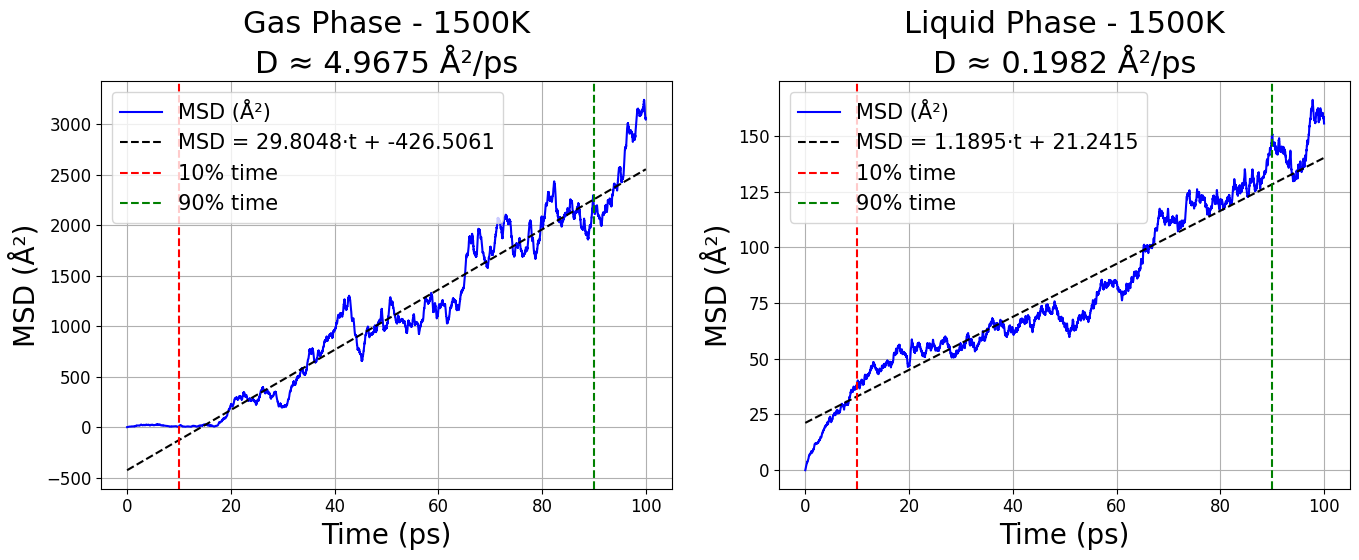

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


fontsize = 20  # Set your desired base font size here

plt.rcParams.update({
    'font.size': fontsize,
    'axes.titlesize': fontsize + 2,
    'axes.labelsize': fontsize,
    'xtick.labelsize': fontsize * 0.6,
    'ytick.labelsize': fontsize * 0.6,
    'legend.fontsize': fontsize * 0.75,
    'figure.titlesize': fontsize
})


def process_file(file_path):
    df = pd.read_csv(file_path, comment='#', delim_whitespace=True, header=None)
    df.columns = ['time_ps', 'RMSD_Ang', 'MSD_Ang2']
    
    def linear_func(t, D, c):
        return D * t + c

    time_min = df['time_ps'].min()
    time_max = df['time_ps'].max()
    time_10 = time_min + 0.10 * (time_max - time_min)
    time_90 = time_min + 0.90 * (time_max - time_min)
    
    mask = (df['time_ps'] >= time_10) & (df['time_ps'] <= time_90)
    time_fit = df['time_ps'][mask].values
    msd_fit = df['MSD_Ang2'][mask].values

    popt, _ = curve_fit(linear_func, time_fit, msd_fit)
    slope, intercept = popt
    D_3D = slope / 6

    msd_linear_fit = linear_func(df['time_ps'], slope, intercept)
    fit_equation = f'MSD = {slope:.4f}·t + {intercept:.4f}'
    
    return df, msd_linear_fit, time_10, time_90, fit_equation, D_3D


def plot_independent_axes(file1, file2, labels=('Plot 1', 'Plot 2'), output_file='msd_independent_axes.png'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Removed sharey=True

    for ax, file_path, label in zip(axes, [file1, file2], labels):
        df, fit, t10, t90, eqn, D = process_file(file_path)

        ax.plot(df['time_ps'], df['MSD_Ang2'], label='MSD (Å²)', color='blue')
        ax.plot(df['time_ps'], fit, '--', color='black', label=eqn)
        ax.axvline(x=t10, color='red', linestyle='--', label='10% time')
        ax.axvline(x=t90, color='green', linestyle='--', label='90% time')
        ax.set_title(f'{label}\nD ≈ {D:.4f} Å²/ps')
        ax.set_xlabel('Time (ps)')
        ax.set_ylabel('MSD (Å²)')
        ax.grid(True)
        ax.legend(loc = "upper left")

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    # plt.show()

plot_independent_axes(
    file1="moldyn/output/gas_md1500K_100ps.dat",
    file2="moldyn/output/liquid_md1500K_100ps.dat",
    labels=('Gas Phase - 1500K', 'Liquid Phase - 1500K'),
    output_file='msd_side_by_side_independent.png'
)
